## Лабораторная работа #6. Решение ОДУ

В работе реализованы:
- Явные и неявные методы Рунге-Кутта 1-4 порядков:
    - Эйлера (явный, 1го порядка)
    - Хойна (явный, 2го порядка)
    - Кутта 3 (явный, 3го порядка)
    - RK4 (явный, 4го порядка)
    - Гаусса-Лежандра 2 (неявный, 2го порядка)
    - Гаусса-Лежаднра 4 (неявный, 4го порядка)
    - Радо IIA (неявный, 3го порядка, L-устойчивый)
    - Лобатто IIIA (неявный, 4го порядка, A-устойчивый)
- Методы Гира (БДФ)
- Методы Розенброка
- Методы Адамса

Проверена эффективность этих методов на жёстких и нежёстких задачах

#### Методы Рунге-Кутты
Решение задачи вида 
$$y = f(x, y), y(x_0) = y_0, x \in [x_0, x_1]$$
Итерационным процессом
$$y_{n+1} = y_{n} + h\sum_{i = 1}^{m}b_ik_i$$
$k$ - это стадии
$$k_i = f(x_n + c_i h, y_n + h\sum_{j=1}^{m}a_{ij}k_j)$$

Методы Рунге-Кутты удобно записывать таблицей Бутчера
\begin{array}{c|cccc}
c_1 & a_{11} & a_{12} & \cdots & a_{1s} \\
c_2 & a_{21} & a_{22} & \cdots & a_{2s} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
c_s & a_{s1} & a_{s2} & \cdots & a_{ss} \\
\hline
& b_1 & b_2 & \cdots & b_s
\end{array}

Условия согласованности метода:
p = 1:
$$\sum_{i=1}^{s} b_i = 1 \quad \Leftrightarrow \quad \mathbf{b}^T \mathbf{1} = 1$$
p = 2:
$$\sum_{i=1}^{s} b_i c_i = \frac{1}{2} \quad \Leftrightarrow \quad \mathbf{b}^T \mathbf{c} = \frac{1}{2}$$
p = 3:
$$\sum_{i=1}^{s} b_i c_i^2 = \frac{1}{3} \quad \Leftrightarrow \quad \mathbf{b}^T \mathbf{c}^2 = \frac{1}{3}$$
$$
\sum_{i=1}^{s}\sum_{j=1}^{s} b_i a_{ij} c_j = \frac{1}{6} \quad \Leftrightarrow \quad \mathbf{b}^T A \mathbf{c} = \frac{1}{6}$$

#### Общий вид многошаговых методов 
$$\sum_{j=0}^{k} \alpha_j y_{n+j} = h \sum_{j=0}^{k} \beta_j f_{n+j}$$
Условия согласованности для p = 1:
$$\sum_{j=0}^{k} \alpha_j = 0, \sum_{j=0}^{k} (j \alpha_j - \beta_j) = 0$$
p = 2:
$$\sum_{j=0}^{k} \left( \frac{j^2}{2} \alpha_j - j \beta_j \right) = 0$$


#### Многошаговые методы Адамса
$$y_{n+1} = y_n + h \sum_{l = 0}^{k} u_{-l} f(x_{n-l}, y_{n-l})$$

#### Методы Розенброка
Решение системы ОДУ
$$\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0$$
Сначала на каждой стадии решается линейная система относительно $k_i$
$$\left( I - h\gamma_{ii} J \right) k_i = h f\left( t_n + \alpha_i h, \, y_n + \sum_{j=1}^{i-1} a_{ij} k_j \right) + h J \sum_{j=1}^{i-1} \gamma_{ij} k_j$$
где 
$$J = \frac{\partial f}{\partial y}(t_n, y_n)$$
$$\alpha_i = \sum_{j=1}^{i-1} a_{ij}$$
Затем записывается решение:
$$y_{n+1} = y_n + \sum_{j=1}^{s} b_j k_j$$

Таблица Бутчера для методов Розенброка:
\begin{array}{c|cc}
\alpha & A & \Gamma \\
\hline
& b^T & 
\end{array}


#### Методы Гира
$$\sum_{j=0}^{k} \alpha_j y_{n+j} = h \beta_k f_{n+k}$$

### Немного об устойчивости 
$$y_{n + 1} = R(z) y_{n}, z \in C$$
где $R(z)$ - функция устойчивости ОДУ, получается при применении численного методы к тестовому уравнению Дайквиста: $y' = \lambda y, \lambda \in C, z = h\lambda$.
ОДУ устойчиво в области $|R(z)| < 1$

In [1]:
import numpy as np
from comp_math.ode.ode_registry import ODERegistry
from comp_math.linear_algebra.objects.matrix import Matrix
from comp_math.linear_algebra.objects.vector import Vector
import matplotlib.pyplot as plt

#### Условия задачи VIII.11.4
Описание движение спутника вокруг планеты на основе решения задачи двух тел.

In [2]:
def viii114_func(tn: float, yn: Vector):
    x = yn[0]
    y = yn[1]
    z = yn[2]
    u = yn[3]
    f = Vector([0, 0, 0, 0])
    f[0] = z # x'
    f[1] = u # y'
    f[2] = - x / (x ** 2 + y ** 2) ** (3 / 2)
    f[3] = - y / (x ** 2 + y ** 2) ** (3 / 2)
    return f

y0 = [0.5, 0, 0, np.sqrt(3)]
t_span = [0, 20]
h = 0.001
dim = 4

Методы для решения нежёстких задач

In [3]:
soft_methods = [
    (ODERegistry.create_solver("euler"), "Метод Эйлера"),
    (ODERegistry.create_solver("heun"),  "Метод Хойна"),
    (ODERegistry.create_solver("kutta"), "Метод Кутта 3"),
    (ODERegistry.create_solver("rk4"), "Метод RK4"),
    (ODERegistry.create_solver("adam1"), "Метод Адамса 1"),
    (ODERegistry.create_solver("adam2"), "Метод Адамса 2"),
    (ODERegistry.create_solver("adam3"), "Метод Адамса 3"),
    (ODERegistry.create_solver("adam4"), "Метод Адамса 4"),
]

Функции для построения графиков

In [4]:
def make_subplot(axes, t, y, ind, ind2, label, labelx="time"):
    axes[ind, ind2].plot(t, y, marker='o')
    axes[ind, ind2].set_title(label + "(" + labelx + ")")
    axes[ind, ind2].set_xlabel(labelx)
    axes[ind, ind2].set_ylabel(label)
    axes[ind, ind2].grid(True, alpha=0.3)


def make_plot(t, y, title=""): 
    fig, axes = plt.subplots(4, 2, figsize=[8,12])

    xs = list(map(lambda yn: yn[0], y))
    ys = list(map(lambda yn: yn[1], y))
    zs = list(map(lambda yn: yn[2], y))
    us = list(map(lambda yn: yn[3], y))

    make_subplot(axes, t, xs, 0, 0, "x")
    make_subplot(axes, t, ys, 0, 1, "y")
    make_subplot(axes, t, zs, 1, 0, "z")
    make_subplot(axes, t, us, 1, 1, "u")
    make_subplot(axes, xs, ys, 2, 0, "y", "x")
    make_subplot(axes, xs, zs, 2, 1, "z", "x")
    make_subplot(axes, xs, us, 3, 0, "u", "x")
    make_subplot(axes, ys, zs, 3, 1, "z", "y")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


В ходе работы графики были построены всеми методами, но, чтобы не засорять отчёт, приведём графики только двух: Кутта 3 и Адамса 4.

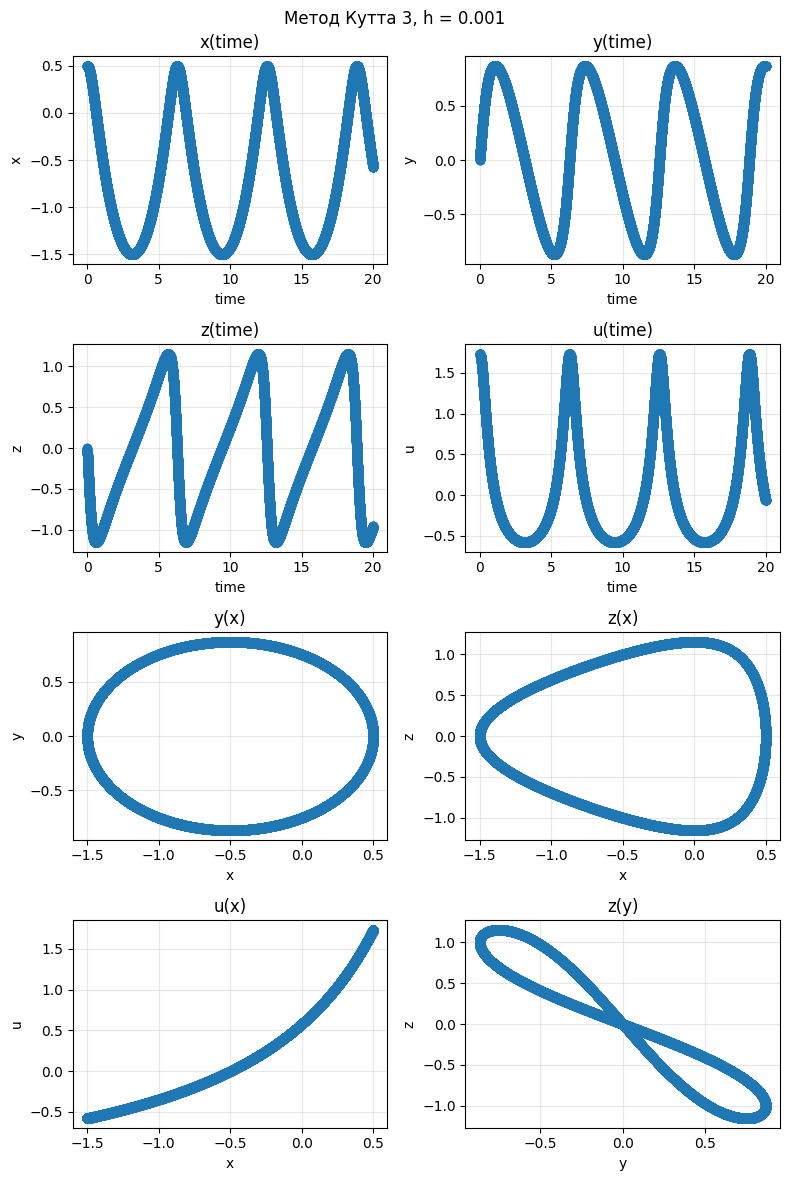

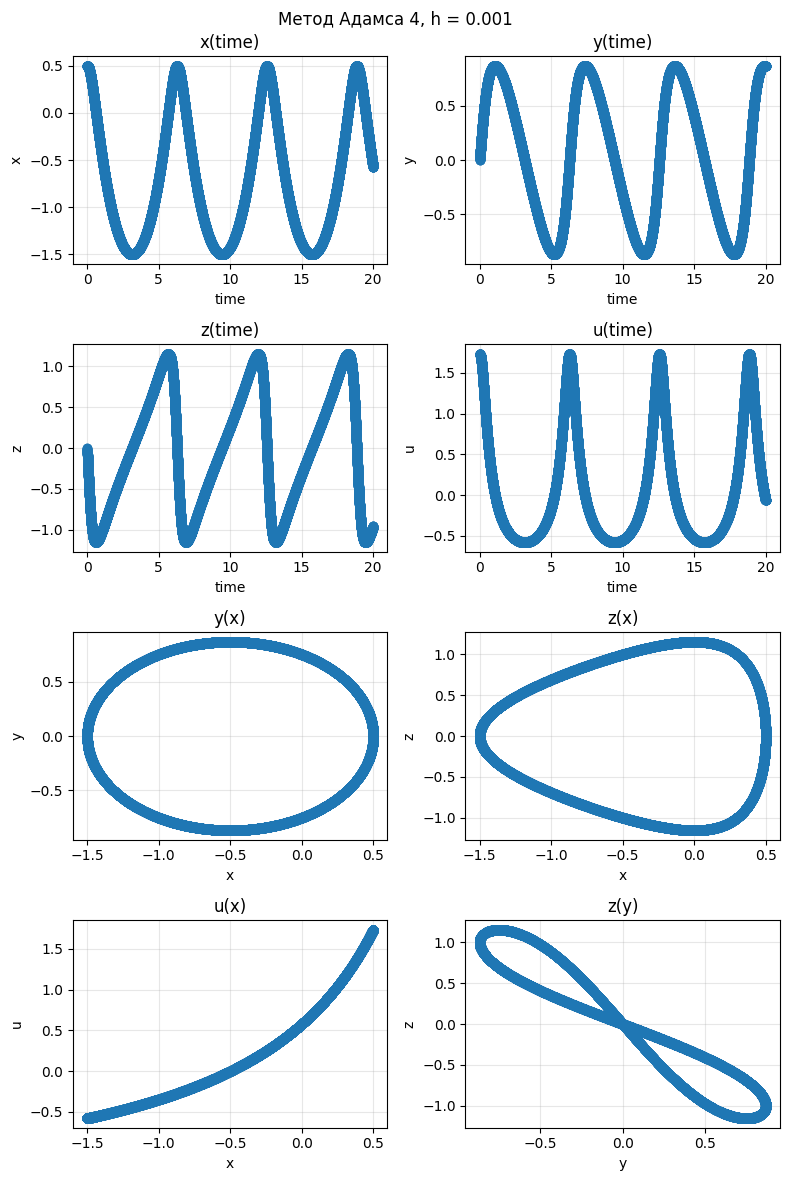

In [6]:
# for method in soft_methods:
#     t, y = method[0].solve(viii114_func, dim, t_span, y0, h)
#     make_plot(t, y, method[1])

for ind in 2, 7:
    t, y = soft_methods[ind][0].solve(viii114_func, dim, t_span, y0, h)
    make_plot(t, y, soft_methods[ind][1] + ", h = " + str(h))

Создание 3д анимации движения спутника в данной модели

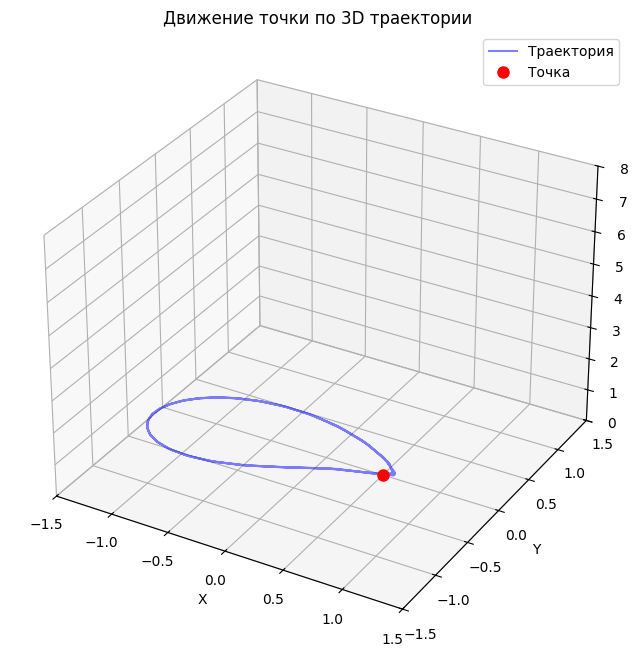

In [9]:
from matplotlib.animation import FuncAnimation

t, y = soft_methods[2][0].solve(viii114_func, dim, t_span, y0, h)

# прореживаем массивы данных, чтобы анимации было легче
t = t[::250]
y = y[::250]

fig = plt.figure(figsize=[10, 8])
ax = fig.add_subplot(111, projection='3d')

line, = ax.plot(list(map(lambda yn: yn[0], y)), 
                list(map(lambda yn: yn[1], y)),
                list(map(lambda yn: yn[2], y)), 
                'b-', alpha=0.5, label='Траектория')

point, = ax.plot([y[0][0]], [y[0][1]], [y[0][2]], 
                 'ro', markersize=8, label='Точка')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(0, 8)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Движение точки по 3D траектории')
ax.legend()

def update(frame):
    point.set_data([y[frame][0]], [y[frame][1]])
    point.set_3d_properties([y[frame][2]])
    
    # Изменение угла обзора
    # ax.view_init(elev=30, azim=frame/2)
    
    return point,

anim = FuncAnimation(fig, update, frames=len(t), interval=50, blit=False)

plt.show() 

anim.save('3d_point_animation.mp4', writer='ffmpeg', fps=30)

Методы для решения жёстких задач

In [10]:
tight_methods = [
    (ODERegistry.create_solver("gauss_legendre_2"), "Метод Гаусса-Лежандра 2"),
    (ODERegistry.create_solver("gauss_legendre_4"), "Метод Гаусса-Лежандра 4"),
    (ODERegistry.create_solver("rado"), "Метод Радо"),
    (ODERegistry.create_solver("lobatto"), "Метод Лобатто"),
    (ODERegistry.create_solver("gear1"), "Гира 1"),
    (ODERegistry.create_solver("gear2"), "Гира 2"),
    (ODERegistry.create_solver("gear3"), "Гира 3"),
    (ODERegistry.create_solver("gear4"), "Гира 4"),
    (ODERegistry.create_solver("rosenbrock1"), "Розенброк 1"),
    (ODERegistry.create_solver("rosenbrock2"), "Розенброк 2"),
    (ODERegistry.create_solver("rosenbrock4"), "Розенброк 4")

]

#### Условие задачи X.9.7
Модель химический реакций Робертсона. Имеет вид, типичный для моделей химической кинетики: в правой части стоят полиномы второй степени от концентраций.


In [16]:
def x97_func(tn: float, y: Vector) -> Vector:
    y_np = y.to_numpy() if isinstance(y, Vector) else np.array(y)
    
    with np.errstate(all='ignore'):
        term1 = 1e4 * y_np[1] * y_np[2]
        term2 = 3e7 * y_np[1] * y_np[1]
        
        f = np.array([
            -0.04 * y_np[0] + term1,
            0.04 * y_np[0] - term1 - term2,
            term2
        ])
        
        f = np.clip(f, -1e100, 1e100)
        f = np.nan_to_num(f, nan=0.0, posinf=1e100, neginf=-1e100)
    
    return Vector(f.tolist())

y0 = [1, 0, 0]
t_span = [0, 40]
h = 0.0001
h10 = h * 10
dim = 3

In [17]:
def make_subplot_tight(axes, t, y, ind, label, labelx="time"):
    axes[ind].plot(t, y, marker='o')
    axes[ind].set_title(label + "(" + labelx + ")")
    axes[ind].set_xlabel(labelx)
    axes[ind].set_ylabel(label)
    axes[ind].grid(True, alpha=0.3)


def make_plot_tight(t, y, title):
    fig, axes = plt.subplots(3, 1, figsize=[8,12])

    y1 = list(map(lambda yn: yn[0], y))
    y2 = list(map(lambda yn: yn[1], y))
    y3 = list(map(lambda yn: yn[2], y))

    make_subplot_tight(axes, t, y1, 0, "y1")
    make_subplot_tight(axes, t, y2, 1, "y2")
    make_subplot_tight(axes, t, y3, 2, "y3")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Посмотрим, как себя ведут явные методы при применении к жёсткой задаче. 

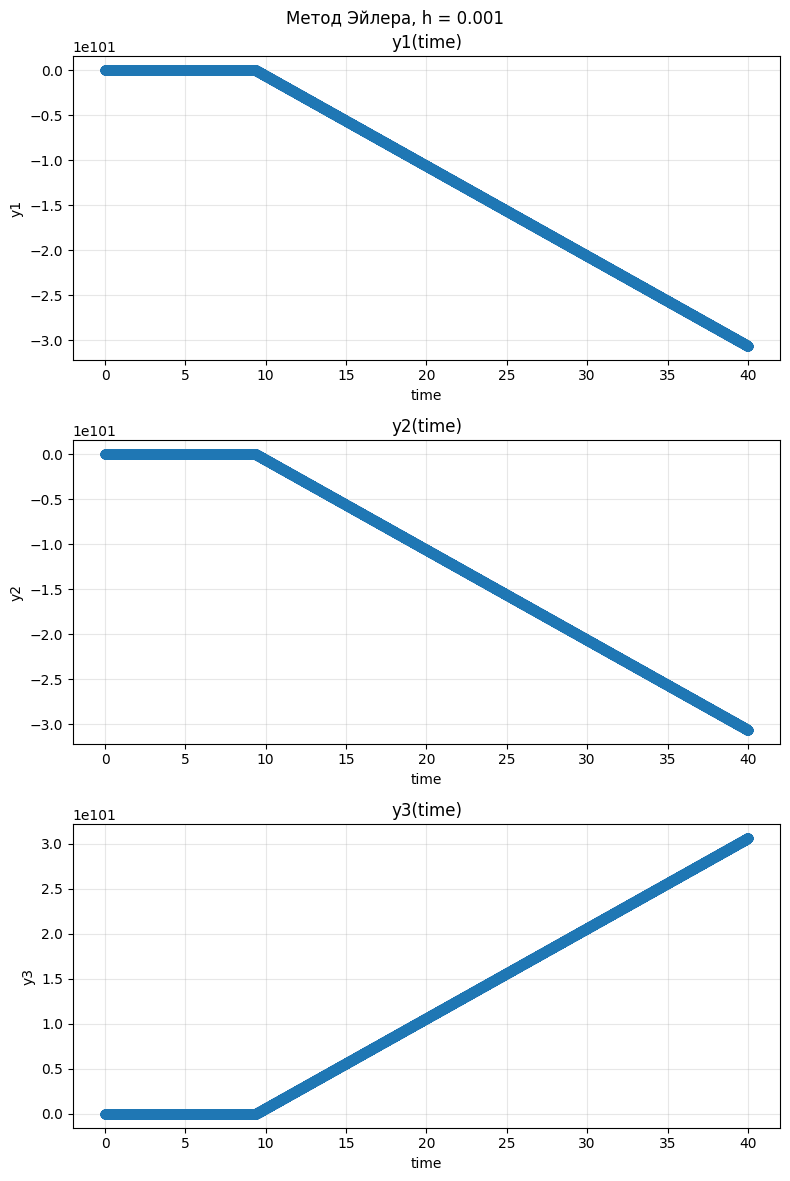

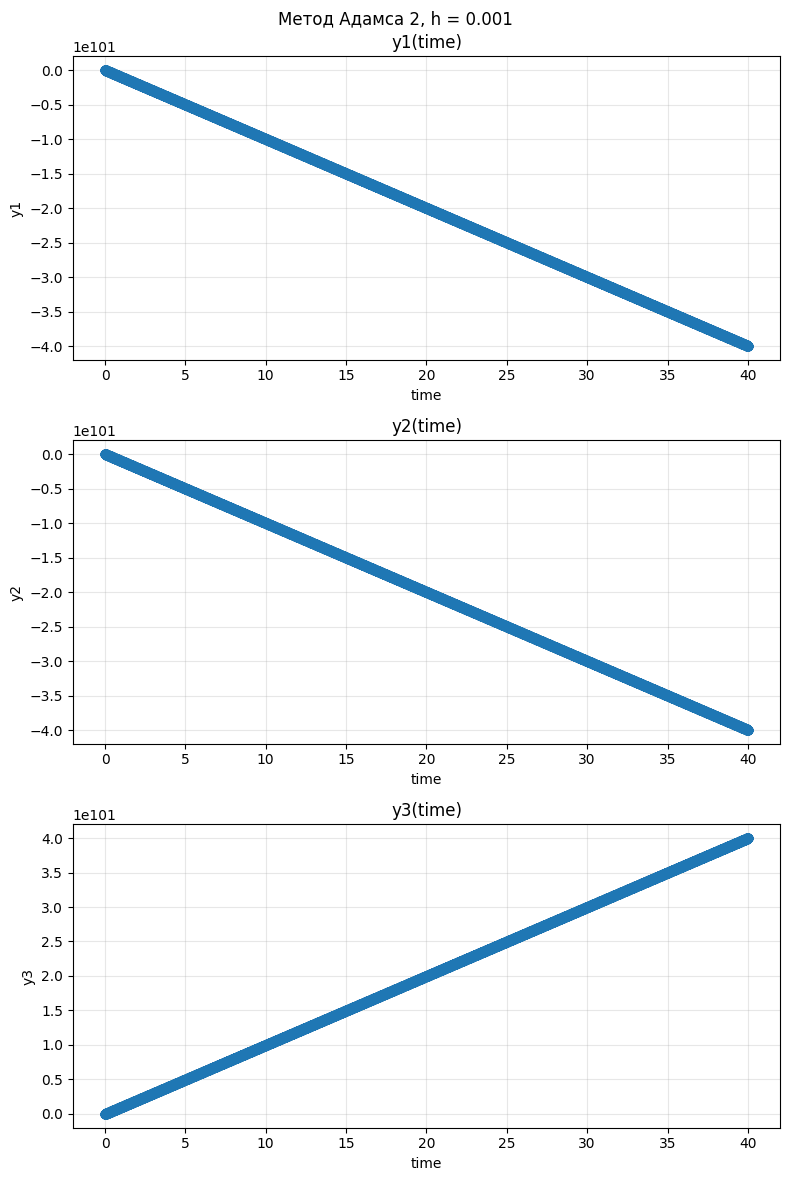

In [18]:
# для демонатрации того, когда явные методы уже неприменимы
for ind in 0, 5:
    t, y = soft_methods[ind][0].solve(x97_func, dim, t_span, y0, h10)
    make_plot_tight(t, y, soft_methods[ind][1] + ", h = " + str(h10))

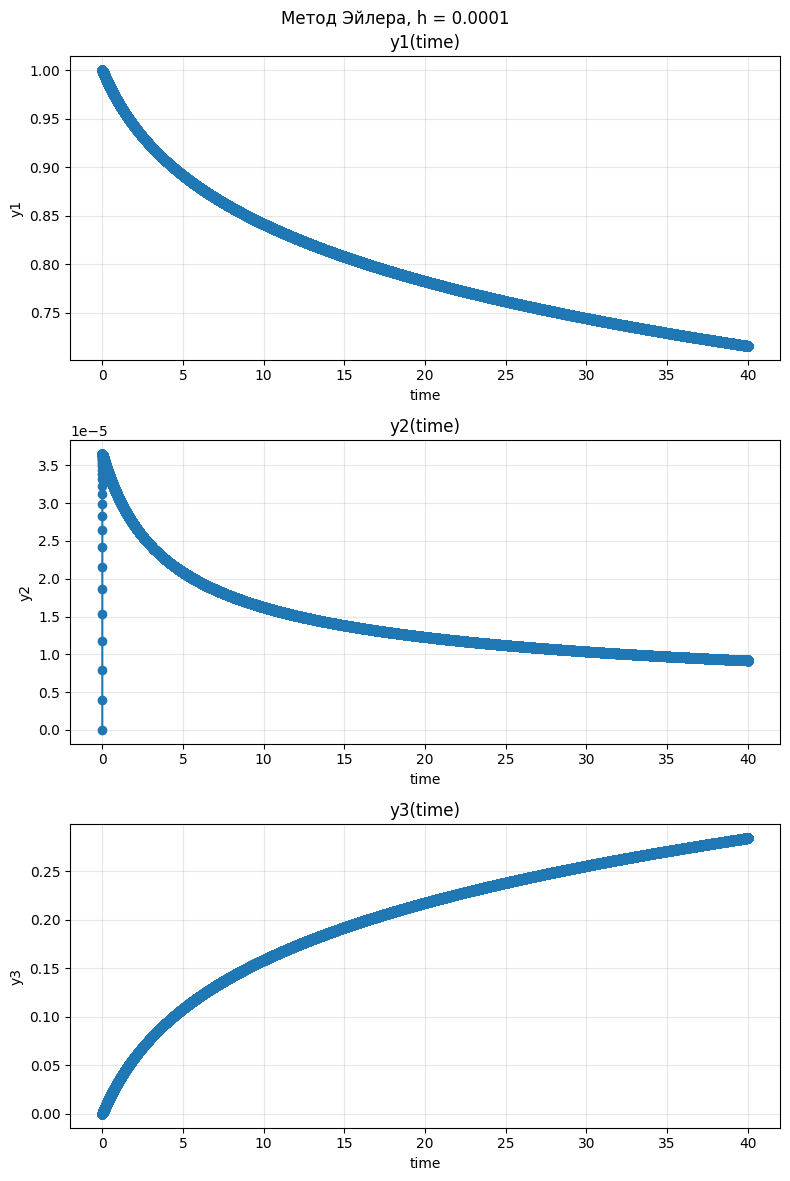

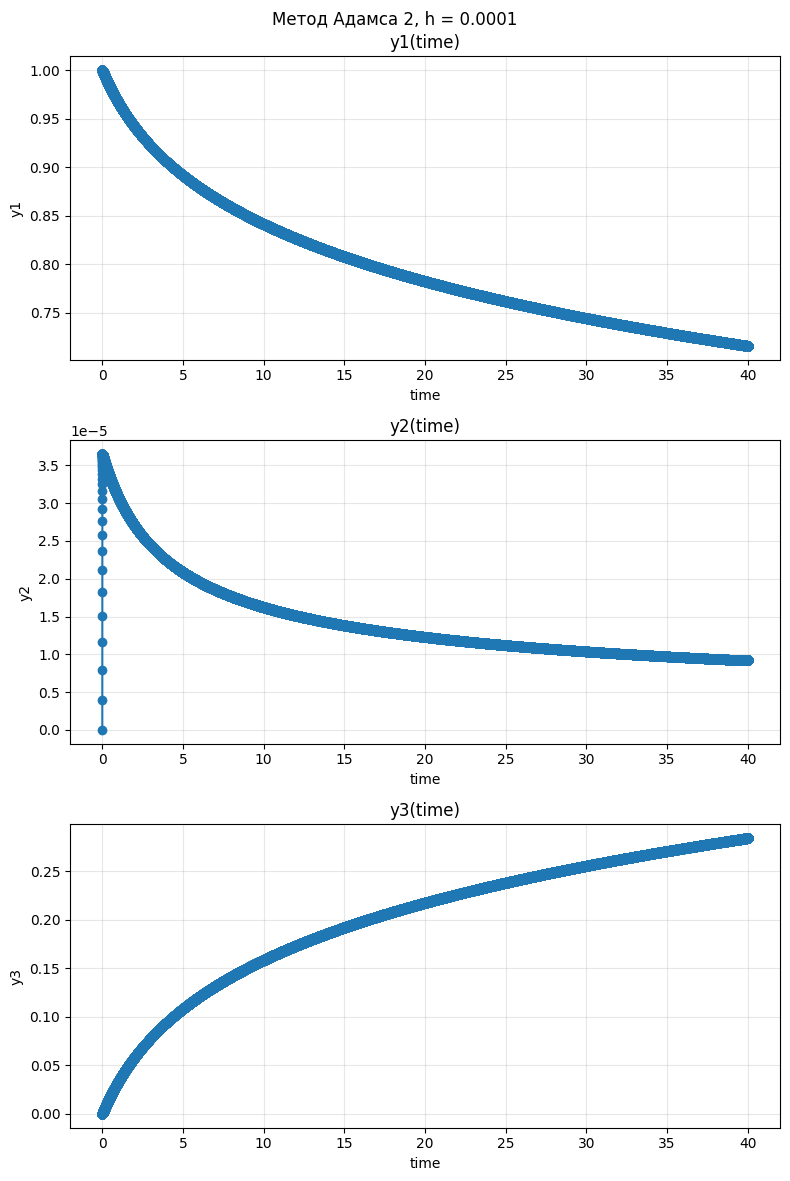

In [19]:
# for method in soft_methods:
#     t, y = method[0].solve(x97_func, dim, t_span, y0, h)
#     make_plot_tight(t, y, method[1])

for ind in 0, 5:
    t, y = soft_methods[ind][0].solve(x97_func, dim, t_span, y0, h)
    make_plot_tight(t, y, soft_methods[ind][1] + ", h = " + str(h))

TODO: на одном графике

Как видно, они сходятся и на жёсткой задаче при h=0.0001) Но при h=0.001 решения становятся нереалистичными

Гира 4


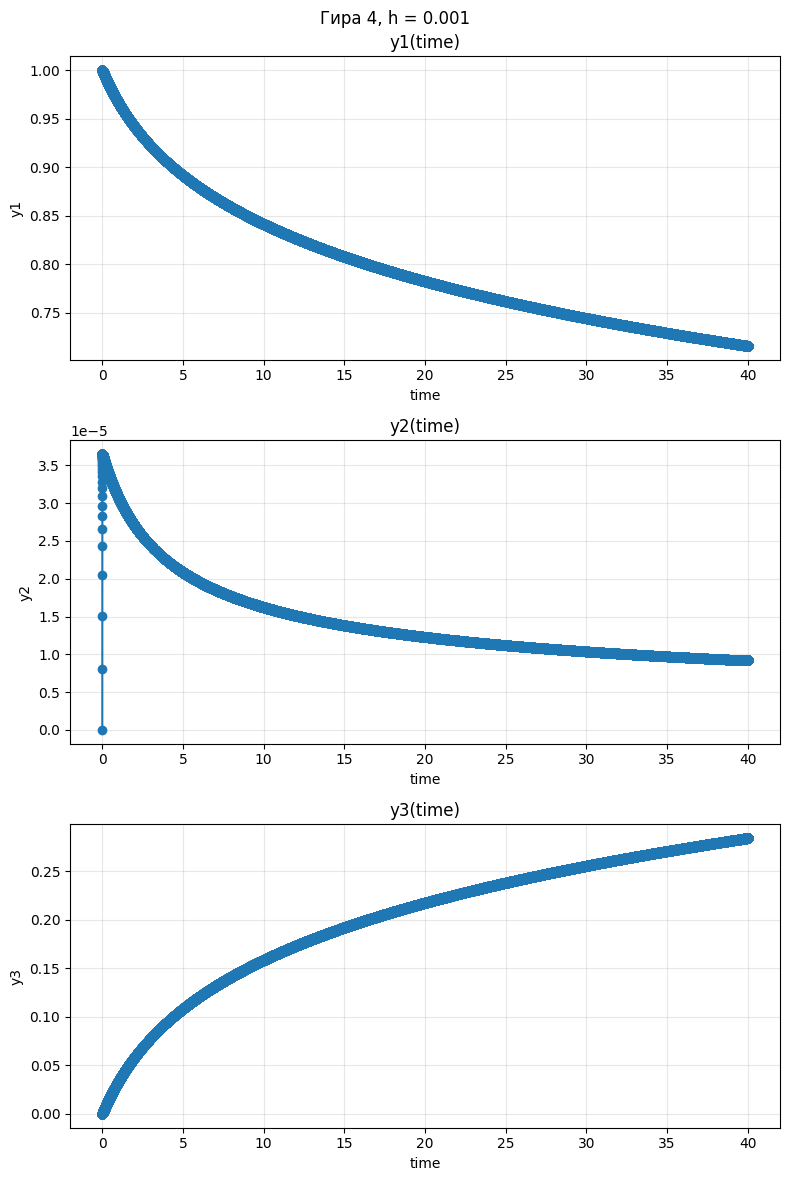

Метод Радо


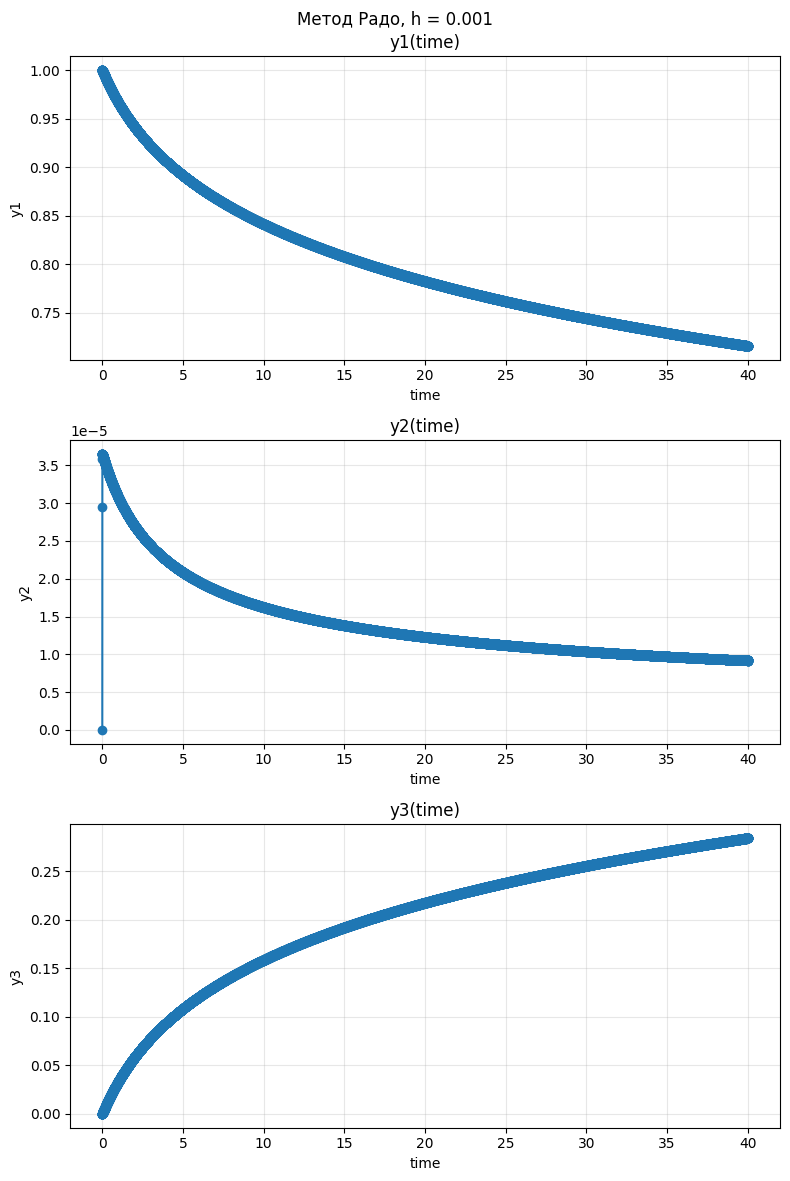

In [25]:
# for method in tight_methods:
#     print(method[1])
#     t, y = method[0].solve(x97_func, dim, t_span, y0, h)
#     make_plot_tight(t, y, method[1])

for ind in 7, 2:
    print(tight_methods[ind][1])
    t, y = tight_methods[ind][0].solve(x97_func, dim, t_span, y0, h10)
    make_plot_tight(t, y, tight_methods[ind][1] + ", h = " + str(h10))

При h = 0.0001 все методы сходятся, но при h = 0.001 "мягкие" методы начинают расходиться. Также начинают расходиться методы Розенброка 2 и 4 (возникает деление на 0 в некоторый момент) 

### Вывод
Эффективность "жёстких" методов зачисит от реализации, так же как и применимость "мягких".